In [ ]:
from tasks import *
import matplotlib.image as mpimg


In [ ]:
keys = [
    'no_removal',
    (Metric.FID, 'itd'),
    (Metric.FID, 'aid'),
    (Metric.IF, 'itd'),
    (Metric.RANDOM, 'itd'),
]
d_filename = {
    (Metric.FID, 'itd'): 'fid_itd',
    (Metric.FID, 'aid'): 'fid_aid',
    (Metric.RANDOM, 'itd'): 'random',
    (Metric.IF, 'itd'): 'if',
    'no_removal': 'no_removal',
}
d_metric_rename = {
    (Metric.FID, 'itd'): 'Influence on FID by ITD (Ours)',
    (Metric.FID, 'aid'): 'Influence on FID by AID (Ours)',
    (Metric.RANDOM, 'itd'): 'Random',
    (Metric.IF, 'itd'): 'Isolation Forest',
    'no_removal': 'No Removal',
}

from_epochs = [49, 0]
name_metrics_infl = [Metric.FID, Metric.FID,  Metric.IF, Metric.RANDOM]
methods_influence = ['itd', 'aid', 'itd', 'itd']
scales_list = [[0.01, 0.001], [0.001, 0.001], [0.01, 0.001],  [0.001, 0.001]]
removal_rates = [0.001,0.002,0.005,0.01,0.02,0.05,0.1,0.2,0.5,0.7,0.9] 
n_epochs = 50
name_metric_eval = Metric.FID
config_base = {
    "from_epochs": from_epochs,
    "depth": 1000,
    "accumulate_decay": 0.999,
    "on_averaged_G": True,
    "dataset_split_infl": "valid",
    "dataset_split_eval": "test",
    "mixing": True,
    "rank_D": 32,
    "rank_G": 32,
    "removal_rates": removal_rates,
    "n_epochs": n_epochs,
    "to_epoch": n_epochs,
    "workspace_directory": "./.processed",
}

tasks = []
for name_metric_infl, scales, method_influence in zip(name_metrics_infl, scales_list, methods_influence):
    config = config_base.copy()
    config["scales"] = scales
    config["name_metric_infl"] = name_metric_infl
    config["name_metric_eval"] = name_metric_eval
    config["method_influence"] = method_influence 
    task = PipelineCleansing(**config)
    tasks.append(task)


In [ ]:
d_gen = {}
for j, (task, name_metric_infl, scales, method_influence) in enumerate(zip(tasks, name_metrics_infl, scales_list, methods_influence)):
    # result_plot, results_plot_cleansing, results_infl_instance, result_eval_ori, results_eval_clean, result_gen_ori, results_gen_clean, task_ori_model, results_best_model_clean, resultss_eval_valid, resultss_eval_test = task.output().load()
    result_plot, results_plot_cleansing, results_infl_instance, result_eval_ori, results_eval_clean, result_gen_ori, results_gen_clean, resultss_eval_valid, resultss_eval_test = task.output().load()
    
    if j == 0:
        d_gen['no_removal'] = [result_gen_ori] * len(from_epochs)
            
    d_gen[(name_metric_infl, method_influence)] = results_gen_clean


[320 366 147 379 153 266 219  27 257 299]


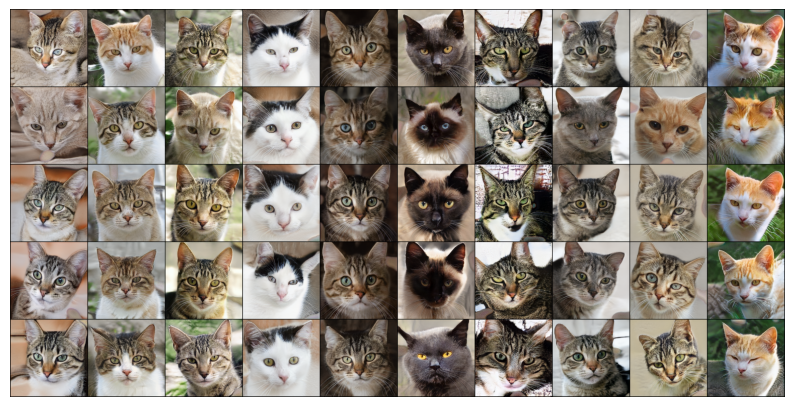

In [16]:
idx_from_epoch = 1
n = 10
# set seed 
np.random.seed(1658944)
idxs = np.random.choice(500, n, replace=False)
print(idxs)
image_cats = []
for key in keys:
    image_cat = d_gen[key][idx_from_epoch][idxs]
    utils.save_image(image_cat, f'resources/tmp/gen_{d_filename[key]}.png', nrow=10, normalize=True, value_range=(-1, 1))
    
    image_cats.append(image_cat)


image_cats = torch.cat(image_cats, dim=0)
# show image_cat
plt.figure(figsize=(10, 10))
plt.imshow(utils.make_grid(image_cats, nrow=10, normalize=True, value_range=(-1, 1)).permute(1, 2, 0))
plt.axis('off')
plt.show()
        